In [4]:
import pandas as pd
import numpy as np


In [15]:
column_value='"fixed acidity":"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'
type(column_value)
column_value=column_value.replace(':',";").split(';')
column=[col.strip('"') for col in column_value]
column


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [5]:
df=pd.read_csv('winequality-red.csv',sep=';')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [13]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [17]:
arr=df.loc[:,['citric acid','alcohol']].values
arr

array([[ 0.  ,  9.4 ],
       [ 0.  ,  9.8 ],
       [ 0.04,  9.8 ],
       ...,
       [ 0.13, 11.  ],
       [ 0.12, 10.2 ],
       [ 0.47, 11.  ]], shape=(1599, 2))

In [19]:
matrix=df.loc[:,['alcohol','density']].values
matrix

array([[ 9.4    ,  0.9978 ],
       [ 9.8    ,  0.9968 ],
       [ 9.8    ,  0.997  ],
       ...,
       [11.     ,  0.99574],
       [10.2    ,  0.99547],
       [11.     ,  0.99549]], shape=(1599, 2))

In [21]:
matrix.T

array([[ 9.4    ,  9.8    ,  9.8    , ..., 11.     , 10.2    , 11.     ],
       [ 0.9978 ,  0.9968 ,  0.997  , ...,  0.99574,  0.99547,  0.99549]],
      shape=(2, 1599))

In [22]:
cov_matrix=np.cov(matrix.T)
cov_matrix

array([[ 1.13564740e+00, -9.97951790e-04],
       [-9.97951790e-04,  3.56202945e-06]])

In [52]:
eigenvalues,eigenvectors=np.linalg.eig(cov_matrix)
eigenvalues

array([1.13564827e+00+0.j, 2.68507580e-06+0.j])

In [65]:
sorted_eigenvalue=np.sort(eigenvalues)[::-1]#top 2 eigenvalues



In [66]:
sorted_eigenvalue


array([1.13564827e+00+0.j, 2.68507580e-06+0.j])

In [ ]:
top_index=np.argsort(eigenvalues)[::-1]
top_index
sorted_eigenvectors=eigenvectors[:,top_index]#sort eigen vectors also
sorted_eigenvectors

array([[ 9.99999614e-01+0.j,  8.78753184e-04+0.j],
       [-8.78753184e-04+0.j,  9.99999614e-01+0.j]])

In [72]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [74]:
df['quality'].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [83]:
df['quality'].median()


np.float64(6.0)

In [82]:
df['quality'].mode()[0]

np.int64(5)

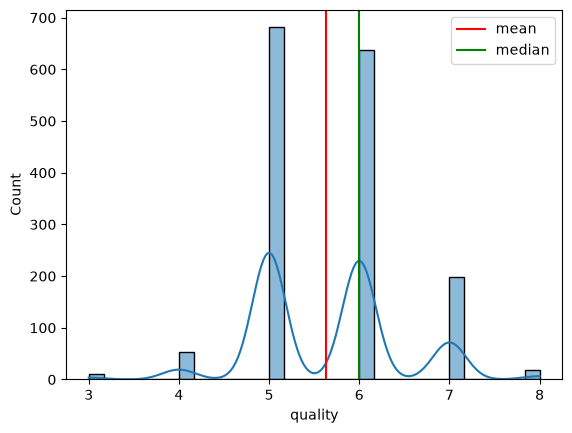

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['quality'],kde=True)
plt.axvline(df['quality'].mean(),label='mean',color='red')
plt.axvline(df['quality'].median(),label='median',color='green')
plt.legend()


<Axes: xlabel='quality', ylabel='count'>

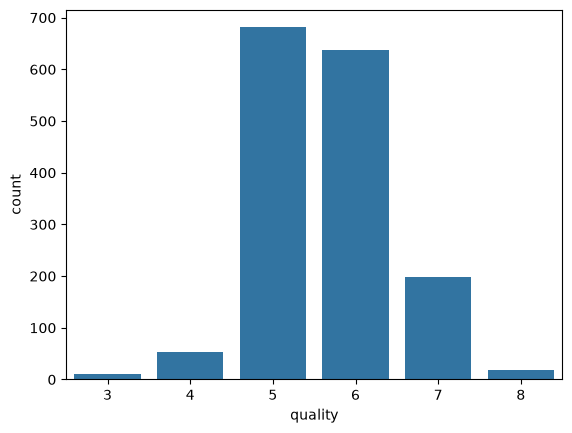

In [92]:
sns.countplot(x='quality', data=df)

In [95]:
df['quality'].skew()

np.float64(0.21780157547366327)

<Axes: ylabel='quality'>

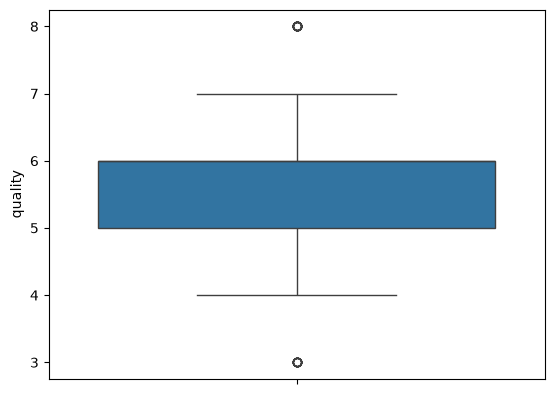

In [97]:
sns.boxplot(df['quality'])